# Esplorazione dati

## Importazione di dati, moduli e pacchetti

In [50]:
#Stile di visualizzazione plot fatti con matplotlib
%matplotlib inline

#Base
import pandas as pd
import numpy as np
import scipy as sp

#Visualizzazione
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [51]:
# IMPORT DATA
TrainData = pd.read_csv('./diabetes_train.csv')
display(TrainData)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Insulin_Sensitivity_Est,BMI_Glucose_Interaction,Random_Lab_Marker,diabetes
0,Male,64.822537,0,0,never,27.097915,6.517746,157.338059,1.220942,4262.942153,38.820127,1
1,Male,59.912290,1,0,never,33.206670,7.971341,148.625701,0.807652,4932.729931,40.381336,1
2,Male,67.853267,0,0,former,30.639790,8.919297,240.733664,1.225950,7372.749574,55.789060,1
3,Male,57.985607,0,0,never,32.609541,8.759698,154.640163,1.432736,5039.552869,40.877685,1
4,Male,70.278133,0,0,current,37.703827,6.261874,169.415511,0.684205,6267.482417,53.671280,1
...,...,...,...,...,...,...,...,...,...,...,...,...
583,Female,19.354174,0,0,former,28.670601,5.248329,160.905601,0.959618,4808.000000,52.632201,0
584,Female,70.000000,0,0,not current,24.750000,3.500000,159.000000,-1.084071,3935.250000,43.652306,0
585,Male,60.000000,0,1,current,29.050000,5.800000,145.000000,-0.468180,4212.250000,58.503956,0
586,Female,27.000000,0,0,No Info,27.320000,6.000000,200.000000,NaN,5464.000000,60.704415,0


## Esplorazione dati

In [52]:
print('TRAINING SET')
TrainData.info()

TRAINING SET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   588 non-null    object 
 1   age                      588 non-null    float64
 2   hypertension             588 non-null    int64  
 3   heart_disease            588 non-null    int64  
 4   smoking_history          588 non-null    object 
 5   bmi                      588 non-null    float64
 6   HbA1c_level              588 non-null    float64
 7   blood_glucose_level      588 non-null    float64
 8   Insulin_Sensitivity_Est  477 non-null    float64
 9   BMI_Glucose_Interaction  588 non-null    float64
 10  Random_Lab_Marker        588 non-null    float64
 11  diabetes                 588 non-null    int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 55.2+ KB


Valori mancanti solamente per l'attributo "Insulin_Sensitivity_Est

In [53]:
print('Categorical features: ')
print(TrainData.select_dtypes(exclude=['float','int']).columns)

Categorical features: 
Index(['gender', 'smoking_history'], dtype='object')


In [54]:
display(TrainData.drop(columns='diabetes').describe())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,Insulin_Sensitivity_Est,BMI_Glucose_Interaction,Random_Lab_Marker
count,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,477.000000,588.000000,588.000000
mean,45.305054,0.078231,0.034014,28.361672,5.812900,152.216394,0.802415,4389.052443,49.747005
std,21.770802,0.268764,0.181418,7.098412,1.399697,51.975885,0.979681,2107.296008,9.283085
min,-0.618799,0.000000,0.000000,13.860000,1.826630,75.779495,-1.995469,1247.400000,19.760969
25%,29.000000,0.000000,0.000000,25.169932,4.852182,126.000000,0.163540,2849.322500,43.214722
50%,50.000000,0.000000,0.000000,27.320000,6.000000,149.829332,0.743667,4085.825000,49.710254
75%,63.046163,0.000000,0.000000,30.940241,6.600000,160.000000,1.394517,5066.750000,55.684763
max,80.307029,1.000000,1.000000,95.690000,9.770172,300.000000,4.126108,12513.000000,72.078046


### Diabete

In [55]:
values, count = np.unique(TrainData['diabetes'].values, return_counts=True)  #Find unique values and their count
display(pd.DataFrame({'Values': values, 'Count': count}).sort_values(by='Count', ascending=False).set_index('Values'))

,Count
Values,
0,441
1,147


### Gender

In [56]:
values, count = np.unique(TrainData['gender'].values, return_counts=True)  #Find unique values and their count
display(pd.DataFrame({'Values': values, 'Count': count}).sort_values(by='Count', ascending=False).set_index('Values'))

,Count
Values,
Male,295
Female,293


I dati sono distribuiti in modo omogeneo sulla base del genere.

In [57]:
#Map to integers
TrainData['gender'] = TrainData['gender'].map(lambda x: 0 if x=='Female' else 1)

### Smoking history

In [58]:
values, count = np.unique(TrainData['smoking_history'].values, return_counts=True)  #Find unique values and their count
display(pd.DataFrame({'Values': values, 'Count': count}).sort_values(by='Count', ascending=False).set_index('Values'))

,Count
Values,
never,206
No Info,192
former,81
current,58
not current,32
ever,19


In [59]:
print(TrainData[TrainData['age'] <= 10]['smoking_history'].value_counts().to_string())

smoking_history
No Info    40
never       5
current     2


In [60]:
for cluster_smoking in TrainData['smoking_history'].unique():
    min_eta = TrainData[TrainData['smoking_history'] == cluster_smoking]['age'].min()
    print(f"Minima età con smoking history = {cluster_smoking} -> {min_eta}")

Minima età con smoking history = never -> 1.32
Minima età con smoking history = former -> 19.0
Minima età con smoking history = current -> 1.4
Minima età con smoking history = No Info -> -0.6187987929311685
Minima età con smoking history = not current -> 11.0
Minima età con smoking history = ever -> 20.0


I dati non sono distribuiti in modo omogeneo sulla base dell'abitudine al fumo.

### Variabili binarie

#### Hypertension

In [61]:
values, count = np.unique(TrainData['hypertension'].values, return_counts=True)  #Find unique values and their count
display(pd.DataFrame({'Values': values, 'Count': count}).sort_values(by='Count', ascending=False).set_index('Values'))

,Count
Values,
0,542
1,46


#### Heart disease

In [62]:
values, count = np.unique(TrainData['heart_disease'].values, return_counts=True)  #Find unique values and their count
display(pd.DataFrame({'Values': values, 'Count': count}).sort_values(by='Count', ascending=False).set_index('Values'))

,Count
Values,
0,568
1,20


Entrambi gli attriuti presentano pochi campioni in proporzione con la data caratteristica.

### Age

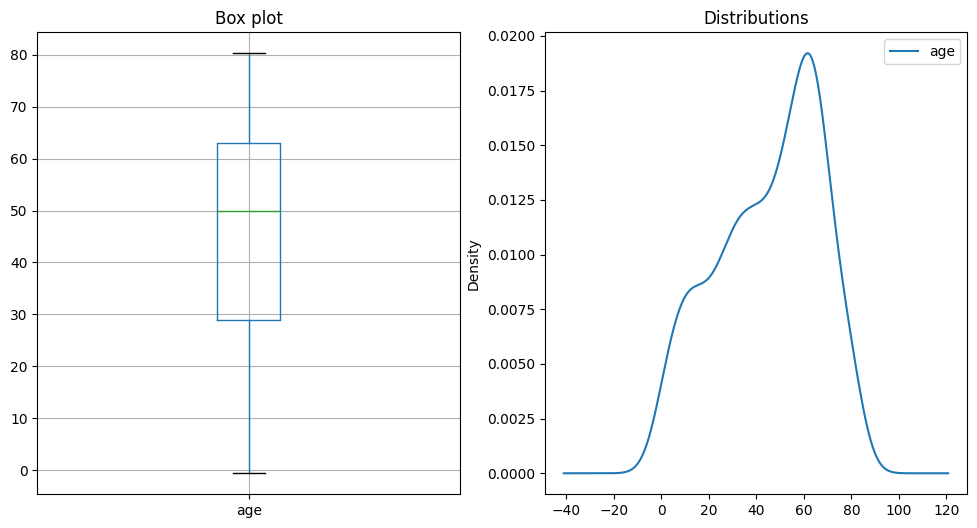

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
TrainData[['age']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['age']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_Age.pdf', format='pdf', bbox_inches='tight')
plt.show()

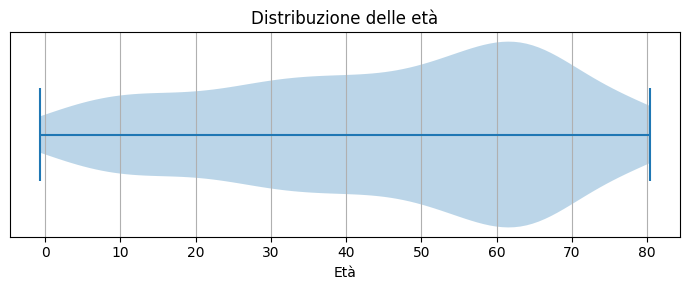

In [ ]:
plt.figure(figsize=(7,3))
plt.title('Distribuzione delle età')
plt.violinplot(TrainData['age'].values,vert=False)
plt.xticks(np.linspace(0,80,9))
plt.yticks([])
plt.xlabel('Età')
plt.grid()
plt.tight_layout()
#plt.savefig('./Plot_Analisi/PlotViolin_Dist_Age.pdf', format='pdf', bbox_inches='tight')
plt.show()

Possiamo notare come ci sia un picco di pazienti intorno ai 60 anni di età, nonostante tutte le età siano rappresentate.

In [65]:
display(TrainData[TrainData['age'] <= 1])

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,Insulin_Sensitivity_Est,BMI_Glucose_Interaction,Random_Lab_Marker,diabetes
311,1,0.080000,0,0,No Info,30.640000,6.600000,130.000000,NaN,3983.20,47.239481,0
409,1,0.720000,0,0,No Info,15.440000,6.500000,160.000000,0.568217,2470.40,45.229166,0
439,1,-0.618799,0,0,No Info,26.739199,5.982008,76.886372,0.392354,2185.60,49.634084,0
518,1,0.240000,0,0,No Info,16.890000,5.700000,126.000000,1.655180,2128.14,67.142346,0


### Indice di massa corporea,  livello di emoglobina glicata,  livello di glucosio nel sangue, stima della sensibilità all'insulina e interazione tra BMI e glucosio

INDICE DI MASSA CORPOREA


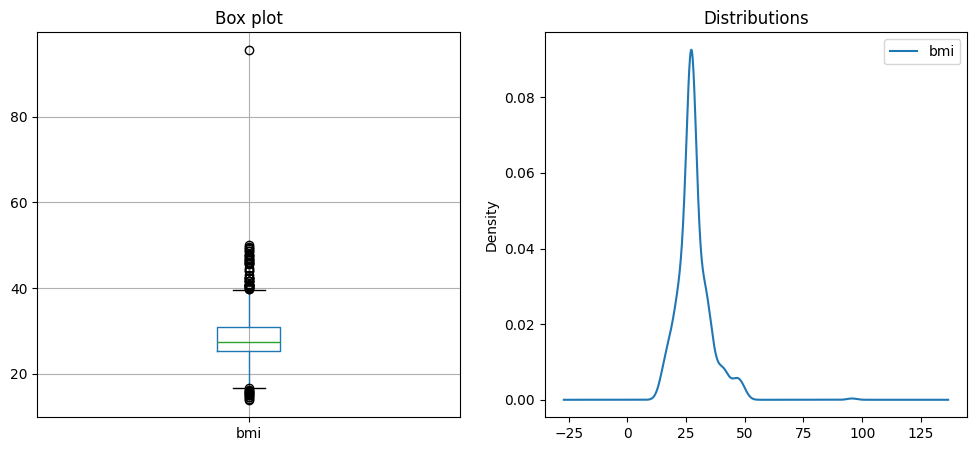

LIVELLO DI EMOGLOBINA GLICATA


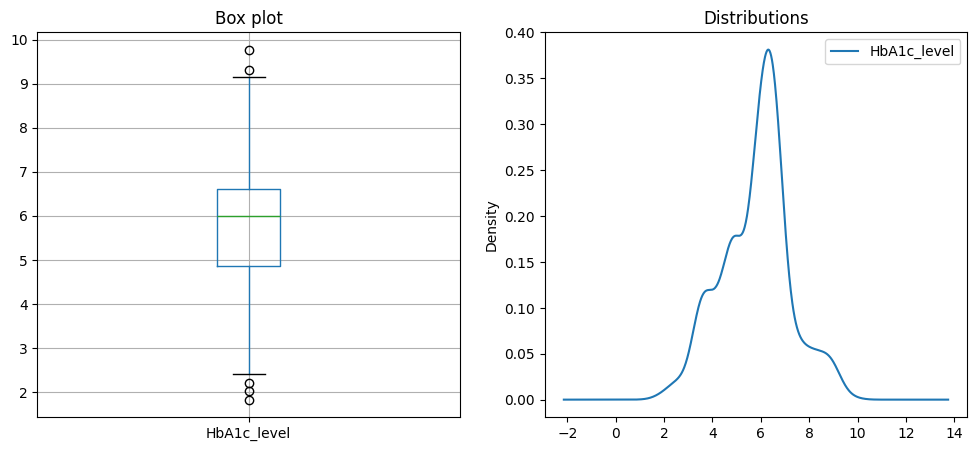

LIVELLO DI GLUCOSIO NEL SANGUE


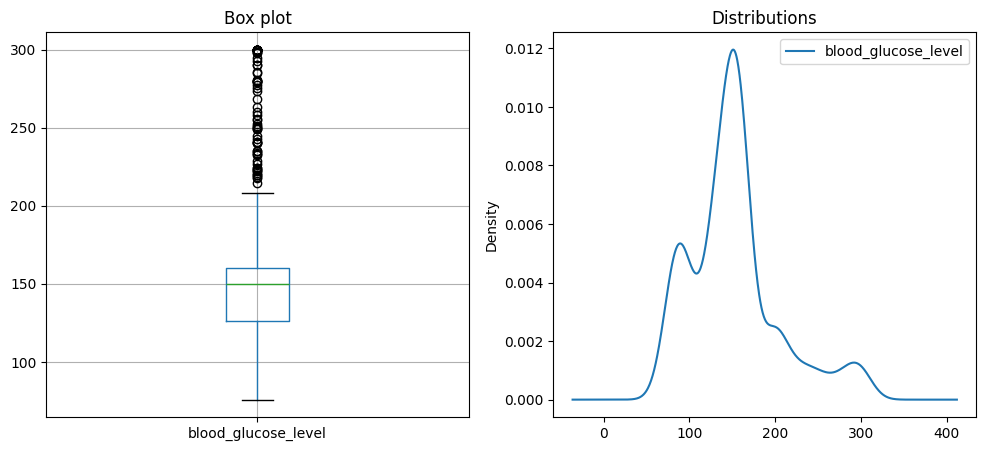

STIMA DELLA SENSIBILITA' ALL'INSULINA


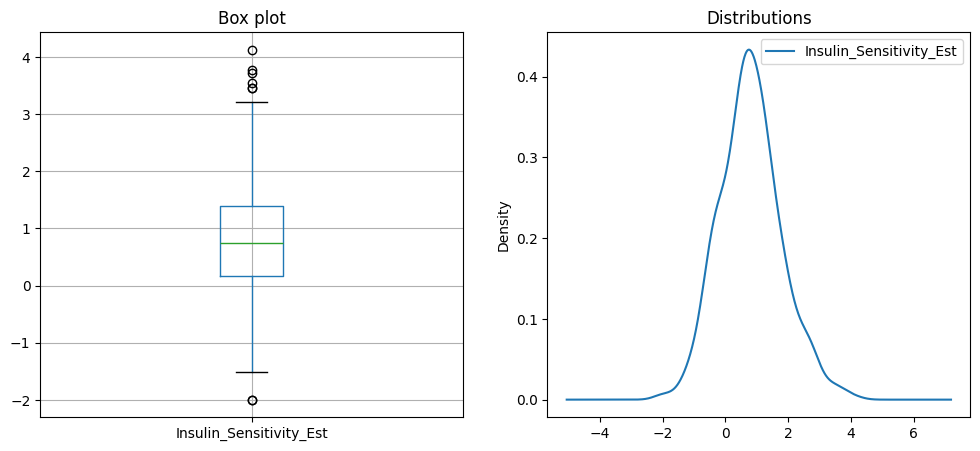

INTERAZIONE TRA BMI E GLUCOSIO


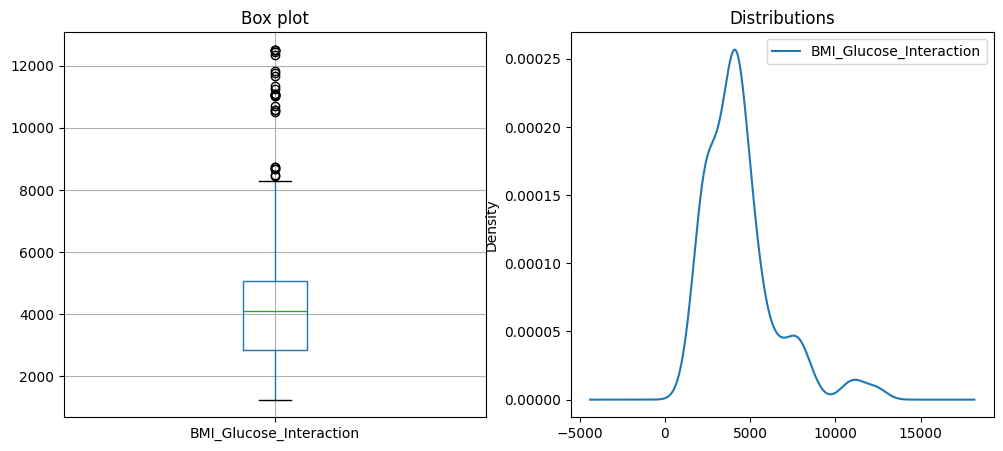

In [ ]:
print('INDICE DI MASSA CORPOREA')
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['bmi']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['bmi']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_Bmi.pdf', format='pdf', bbox_inches='tight')
plt.show()

print('LIVELLO DI EMOGLOBINA GLICATA')
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['HbA1c_level']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['HbA1c_level']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_HbA1c.pdf', format='pdf', bbox_inches='tight')
plt.show()

print('LIVELLO DI GLUCOSIO NEL SANGUE')
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['blood_glucose_level']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['blood_glucose_level']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_GlucoseLevel.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("STIMA DELLA SENSIBILITA' ALL'INSULINA")
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['Insulin_Sensitivity_Est']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['Insulin_Sensitivity_Est']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_InsulinSentivity.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("INTERAZIONE TRA BMI E GLUCOSIO")
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['BMI_Glucose_Interaction']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['BMI_Glucose_Interaction']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_BmiGlucose.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [67]:
print("L'indice di massa corporea massimo è:", np.max(TrainData['bmi']))

L'indice di massa corporea massimo è: 95.69


È possibile individuare la presenza di errori.\
Un valore di indice di massa corporea pari a 95,69 appare anomalo e con ogni probabilità è frutto di un errore nella raccolta del dato, oppure rappresenta un caso estremamente raro che può essere ragionevolmente escluso dall'analisi. A titolo di confronto, l'uomo con il più alto BMI mai registrato alla fine del Novecento pesava 362 kg, con un indice di massa corporea pari a 105,3.

SENSIBILITA' ALL'INSULINA


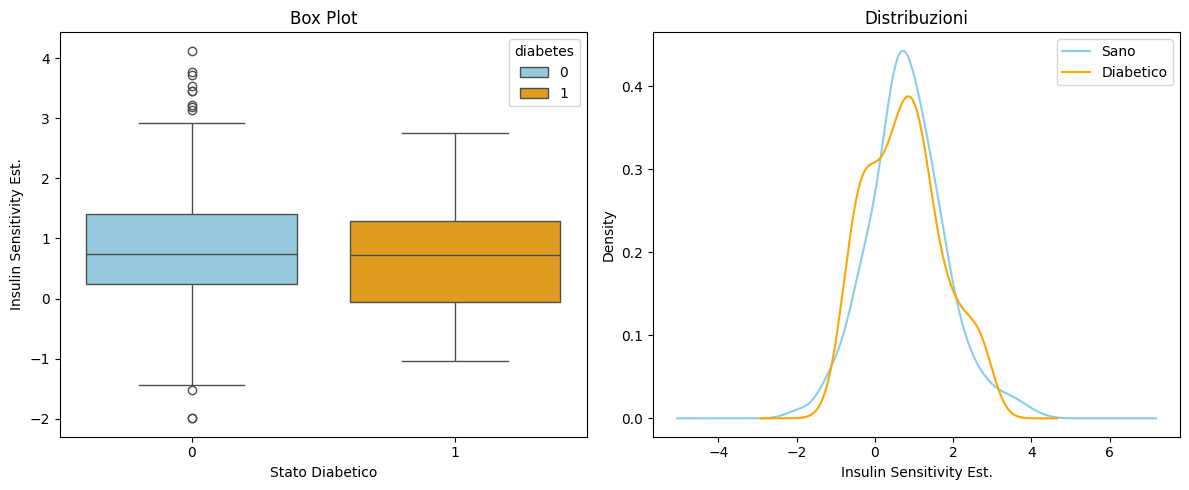

In [68]:
print("SENSIBILITA' ALL'INSULINA")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
sns.boxplot(
    data=TrainData,
    x='diabetes',
    y='Insulin_Sensitivity_Est',
    hue='diabetes',
    palette={0: 'skyblue', 1: 'orange'},
    ax=axs[0]
)
axs[0].set_title('Box Plot')
axs[0].set_xlabel('Stato Diabetico')
axs[0].set_ylabel('Insulin Sensitivity Est.')

# Density plot
TrainData[TrainData['diabetes'] == 0]['Insulin_Sensitivity_Est'].plot.density(
    ax=axs[1], label='Sano', color='skyblue'
)
TrainData[TrainData['diabetes'] == 1]['Insulin_Sensitivity_Est'].plot.density(
    ax=axs[1], label='Diabetico', color='orange'
)
axs[1].set_title('Distribuzioni')
axs[1].set_xlabel('Insulin Sensitivity Est.')
axs[1].legend()

#plt.savefig('./Plot_Analisi/Plot_Diabetes_BmiGlucose.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

### Random lab marker

RANDOM LAB MARKER


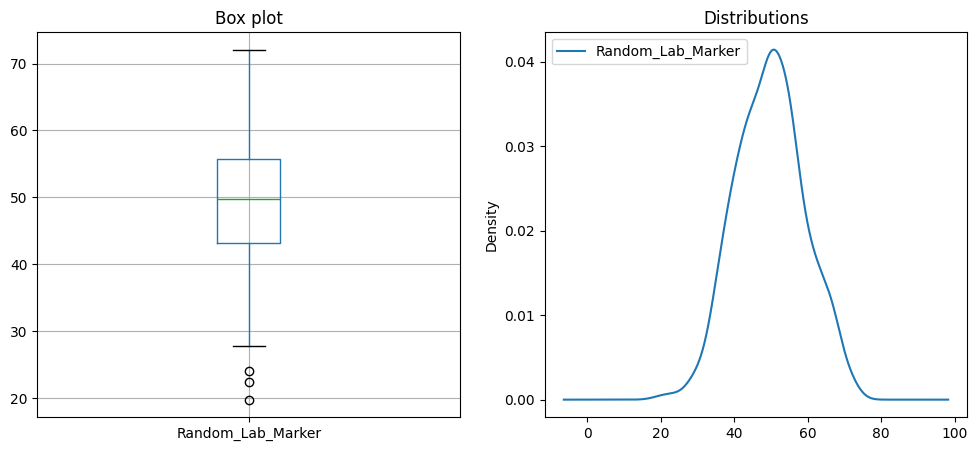

In [ ]:
print('RANDOM LAB MARKER')
fig, axs = plt.subplots(1,2, figsize=(12,5))
TrainData[['Random_Lab_Marker']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
TrainData[['Random_Lab_Marker']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
#plt.savefig('./Plot_Analisi/Plot_Dist_Marker.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Relations between variables

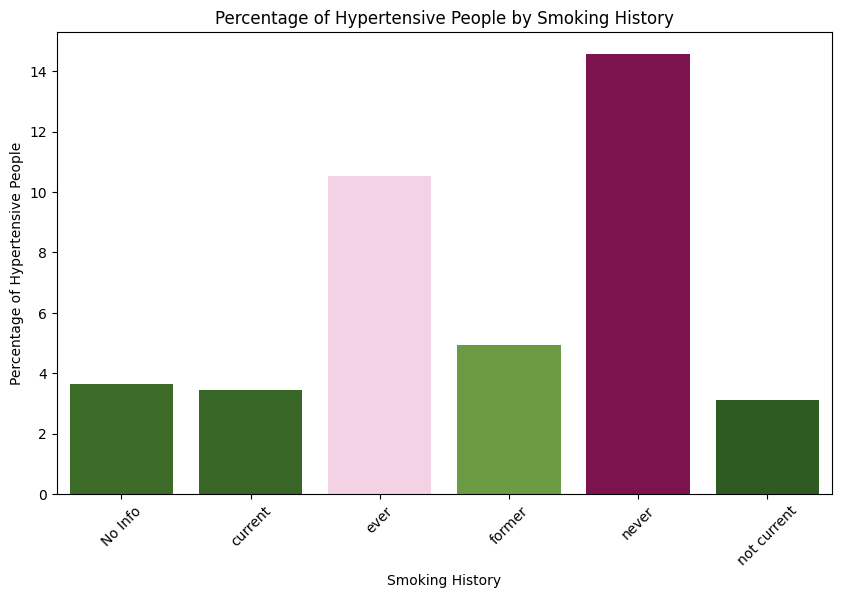

In [ ]:
# Plot smoking history vs hypertension with percentage of hypertensive people
plt.figure(figsize=(10, 6))
hypertension_percentage = TrainData.groupby('smoking_history')['hypertension'].mean() * 100

# palette based on percetage of diabetic people
norm = plt.Normalize(hypertension_percentage.min(), hypertension_percentage.max())
colors = list(sns.color_palette("PiYG_r", as_cmap=True)(norm(hypertension_percentage)))

sns.barplot(x=hypertension_percentage.index, y=hypertension_percentage.values, 
            hue=hypertension_percentage.index, palette=colors)
plt.title("Percentage of Hypertensive People by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Percentage of Hypertensive People")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_HypertensionSmoking.pdf', format='pdf', bbox_inches='tight')
plt.show()

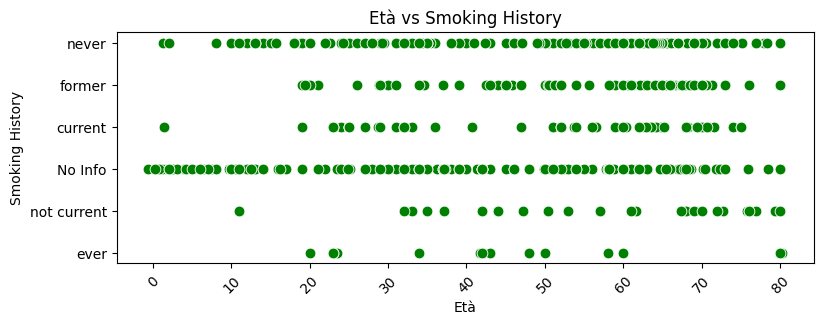

In [ ]:
plt.figure(figsize=(9, 3))
sns.scatterplot(data=TrainData, y='smoking_history', x='age', color="green", s=60)
plt.title("Età vs Smoking History")
plt.ylabel("Smoking History")
plt.xlabel("Età")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_AgeSmoking.pdf', format='pdf', bbox_inches='tight')
plt.show()

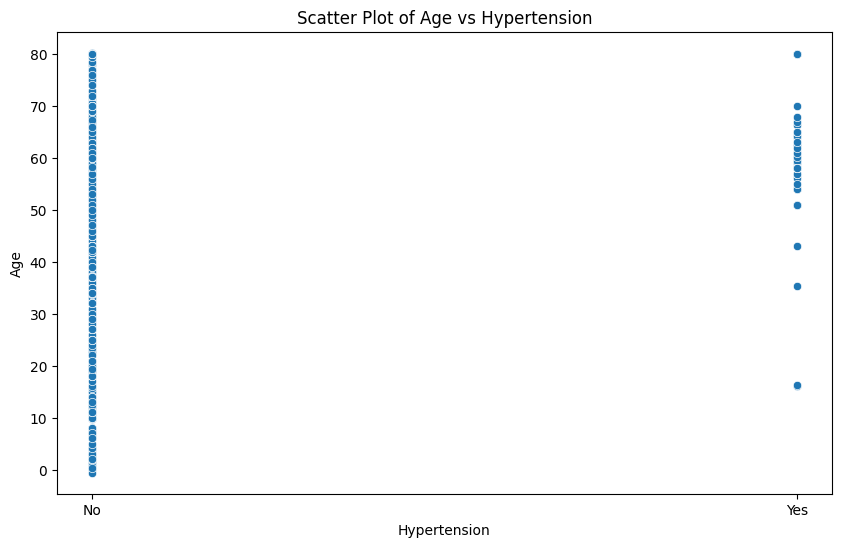

In [ ]:
# Scatter plot of age on y-axis and hypertension on x-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TrainData, x='hypertension', y='age')
plt.title("Scatter Plot of Age vs Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Age")
plt.xticks([0, 1], labels=["No", "Yes"])
#plt.savefig('./Plot_Analisi/Plot_AgeHypertension.pdf', format='pdf', bbox_inches='tight')
plt.show()

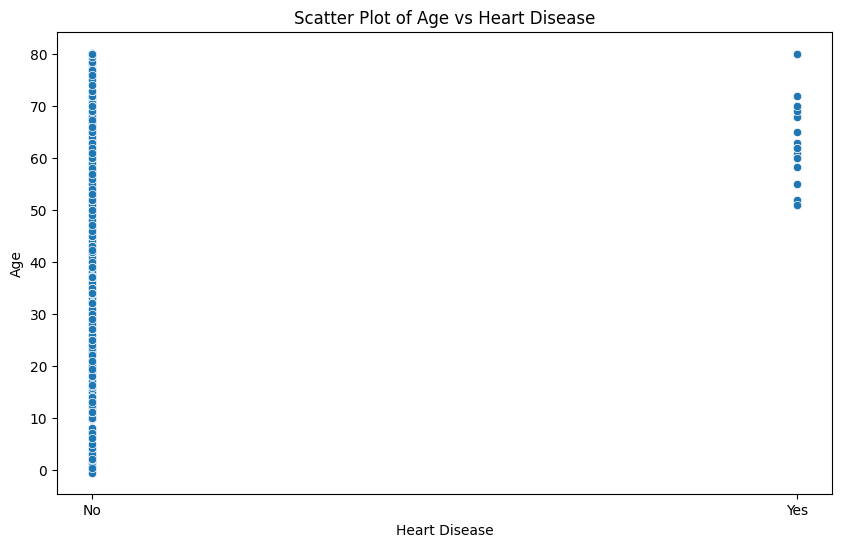

In [ ]:
# Scatter plot of age on y-axis and heart_disease on x-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TrainData, x='heart_disease', y='age')
plt.title("Scatter Plot of Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0, 1], labels=["No", "Yes"])
#plt.savefig('./Plot_Analisi/Plot_AgeHeart.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Relations with Diabete

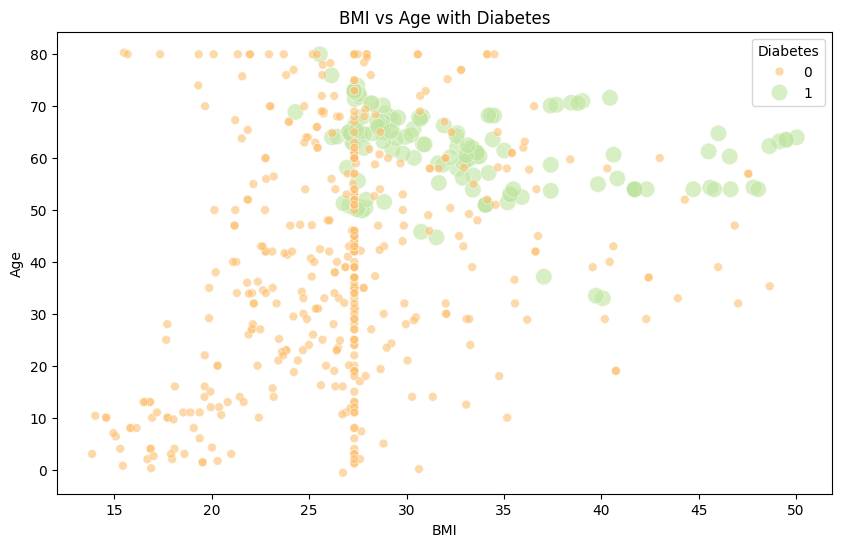

In [74]:
# Bubble plot of BMI vs Age with Diabetes as size
plt.figure(figsize=(10, 6))
# Use diabetes directly for size, but map to fixed sizes for legend clarity
size_map = {0: 40, 1: 140}
sizes = TrainData[TrainData['bmi']<70]['diabetes'].map(size_map)
sns.scatterplot(
    data=TrainData[TrainData['bmi']<70],
    x='bmi',
    y='age',
    size='diabetes',
    sizes=size_map,
    hue='diabetes',
    palette="Spectral",
    alpha=0.6,
    legend='full'
)
plt.title("BMI vs Age with Diabetes")
plt.xlabel("BMI")
plt.ylabel("Age")
plt.legend(title="Diabetes", loc='upper right')
plt.show()

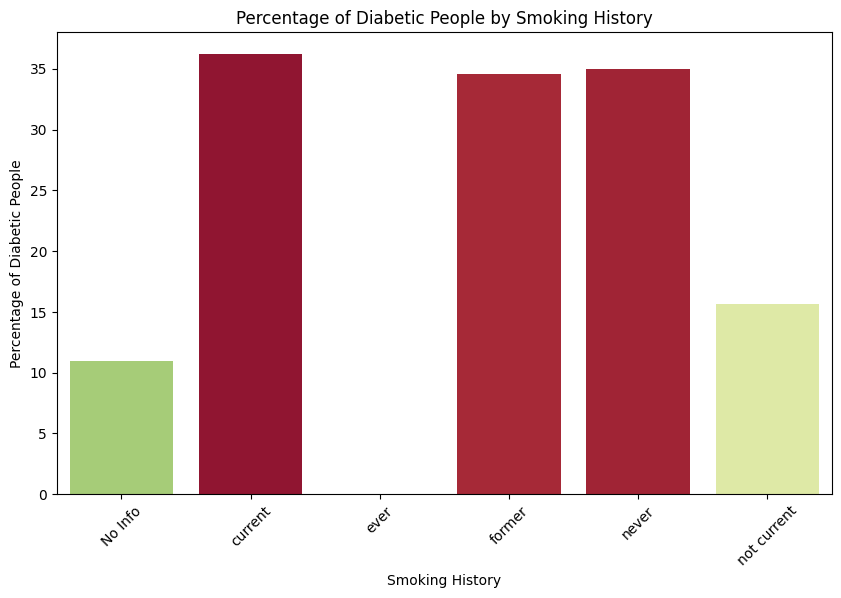

In [ ]:
# Plot smoking history vs diabetes with percentage of diabetic people
plt.figure(figsize=(10, 6))
diabetes_percentage = TrainData.groupby('smoking_history')['diabetes'].mean() * 100

# palette based on percetage of diabetic people
norm = plt.Normalize(diabetes_percentage.min(), diabetes_percentage.max())
colors = list(sns.color_palette("RdYlGn_r", as_cmap=True)(norm(diabetes_percentage)))

sns.barplot(x=diabetes_percentage.index, y=diabetes_percentage.values, hue=diabetes_percentage.index,
             palette=colors)
plt.title("Percentage of Diabetic People by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Percentage of Diabetic People")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_SmokingDiabetes.pdf', format='pdf', bbox_inches='tight')
plt.show()

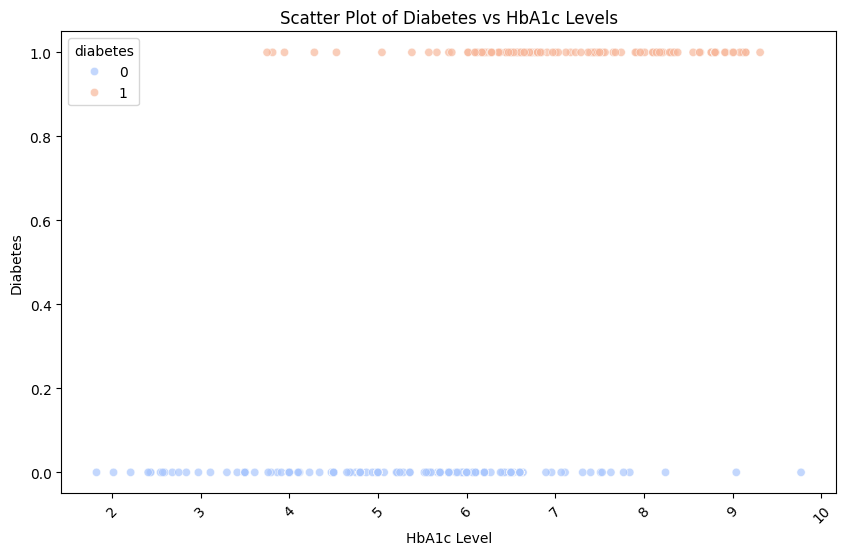

In [ ]:
# Scatter plot of diabetes vs HbA1c levels
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TrainData, x='HbA1c_level', y='diabetes', hue='diabetes', palette="coolwarm", 
                alpha=0.7)
plt.title("Scatter Plot of Diabetes vs HbA1c Levels")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_HbA1cDiabetes.pdf', format='pdf', bbox_inches='tight')
plt.show()

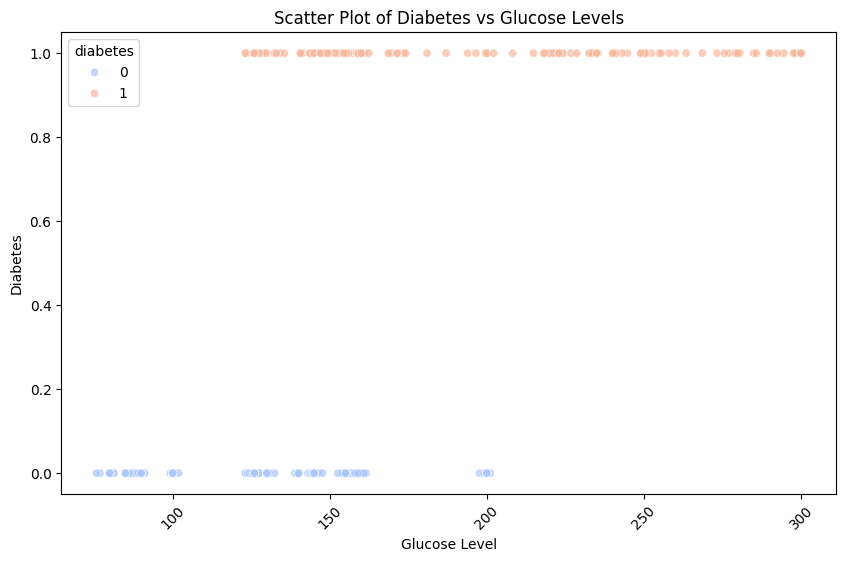

In [ ]:
# Scatter plot of diabetes vs glucose levels
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TrainData, x='blood_glucose_level', y='diabetes', hue='diabetes', 
                palette="coolwarm", alpha=0.7)
plt.title("Scatter Plot of Diabetes vs Glucose Levels")
plt.xlabel("Glucose Level")
plt.ylabel("Diabetes")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_GlucoseDiabetes.pdf', format='pdf', bbox_inches='tight')
plt.show()

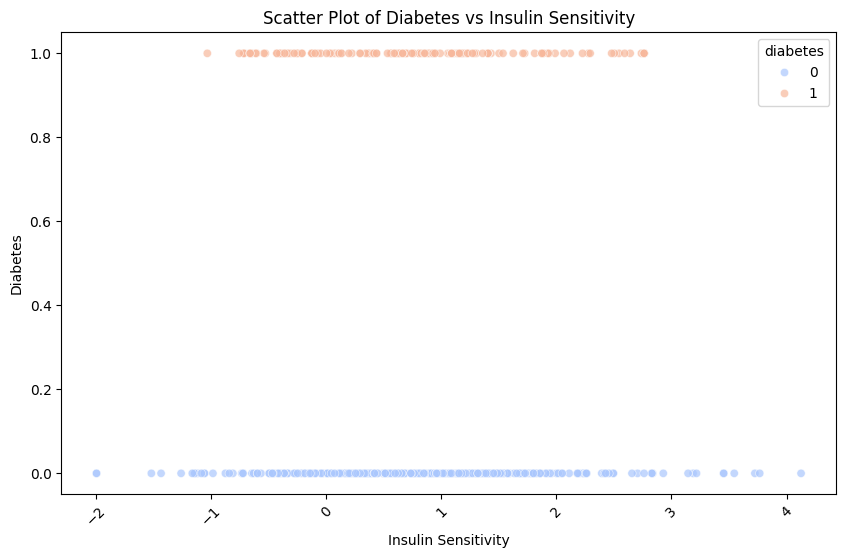

In [ ]:
# Scatter plot of diabetes vs insulin sensitivity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TrainData, x='Insulin_Sensitivity_Est', y='diabetes', hue='diabetes', 
                palette="coolwarm", alpha=0.7)
plt.title("Scatter Plot of Diabetes vs Insulin Sensitivity")
plt.xlabel("Insulin Sensitivity")
plt.ylabel("Diabetes")
plt.xticks(rotation=45)
#plt.savefig('./Plot_Analisi/Plot_InsulinDiabetes.pdf', format='pdf', bbox_inches='tight')
plt.show()

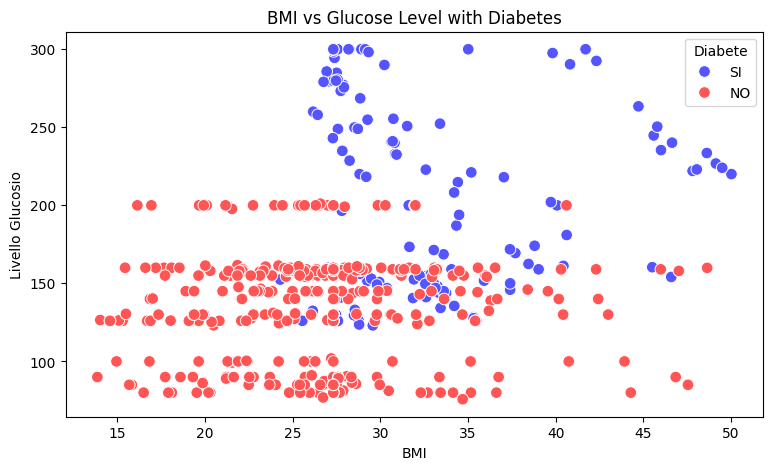

In [ ]:
# Plot diabetes vs BMI and Glucose interaction
plt.figure(figsize=(9, 5))
data_mapped = TrainData.assign(diabetes_str=TrainData['diabetes'].map({0: 'NO', 1: 'SI'}))
sns.scatterplot(data=data_mapped[data_mapped['bmi']<70], x='bmi', y='blood_glucose_level', 
                hue='diabetes_str', palette="seismic", alpha=1, s=70)
plt.title("BMI vs Glucose Level with Diabetes")
plt.xlabel("BMI")
plt.ylabel("Livello Glucosio")
plt.legend(title="Diabete", loc='upper right')
#plt.savefig('./Plot_Analisi/Plot_BmiGlucoseDiabetes.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Correlazione

#### Elaborazione provvisoria dei dati 

Codifica Smoking info, sostituzione dati mancanti con media e rimozione errori su BMI ed age.

In [80]:
#Encoding smoking data
data_ohe = pd.get_dummies(TrainData)
data_noNull = data_ohe.fillna(data_ohe.mean(numeric_only=True))
data_noNull_noOut = data_noNull[(data_noNull['age'] > 0) & (data_noNull['bmi'] < 70)] 
display(data_noNull_noOut)

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,Insulin_Sensitivity_Est,BMI_Glucose_Interaction,Random_Lab_Marker,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1,64.822537,0,0,27.097915,6.517746,157.338059,1.220942,4262.942153,38.820127,1,False,False,False,False,True,False
1,1,59.912290,1,0,33.206670,7.971341,148.625701,0.807652,4932.729931,40.381336,1,False,False,False,False,True,False
2,1,67.853267,0,0,30.639790,8.919297,240.733664,1.225950,7372.749574,55.789060,1,False,False,False,True,False,False
3,1,57.985607,0,0,32.609541,8.759698,154.640163,1.432736,5039.552869,40.877685,1,False,False,False,False,True,False
4,1,70.278133,0,0,37.703827,6.261874,169.415511,0.684205,6267.482417,53.671280,1,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,0,19.354174,0,0,28.670601,5.248329,160.905601,0.959618,4808.000000,52.632201,0,False,False,False,True,False,False
584,0,70.000000,0,0,24.750000,3.500000,159.000000,-1.084071,3935.250000,43.652306,0,False,False,False,False,False,True
585,1,60.000000,0,1,29.050000,5.800000,145.000000,-0.468180,4212.250000,58.503956,0,False,True,False,False,False,False
586,0,27.000000,0,0,27.320000,6.000000,200.000000,0.802415,5464.000000,60.704415,0,True,False,False,False,False,False


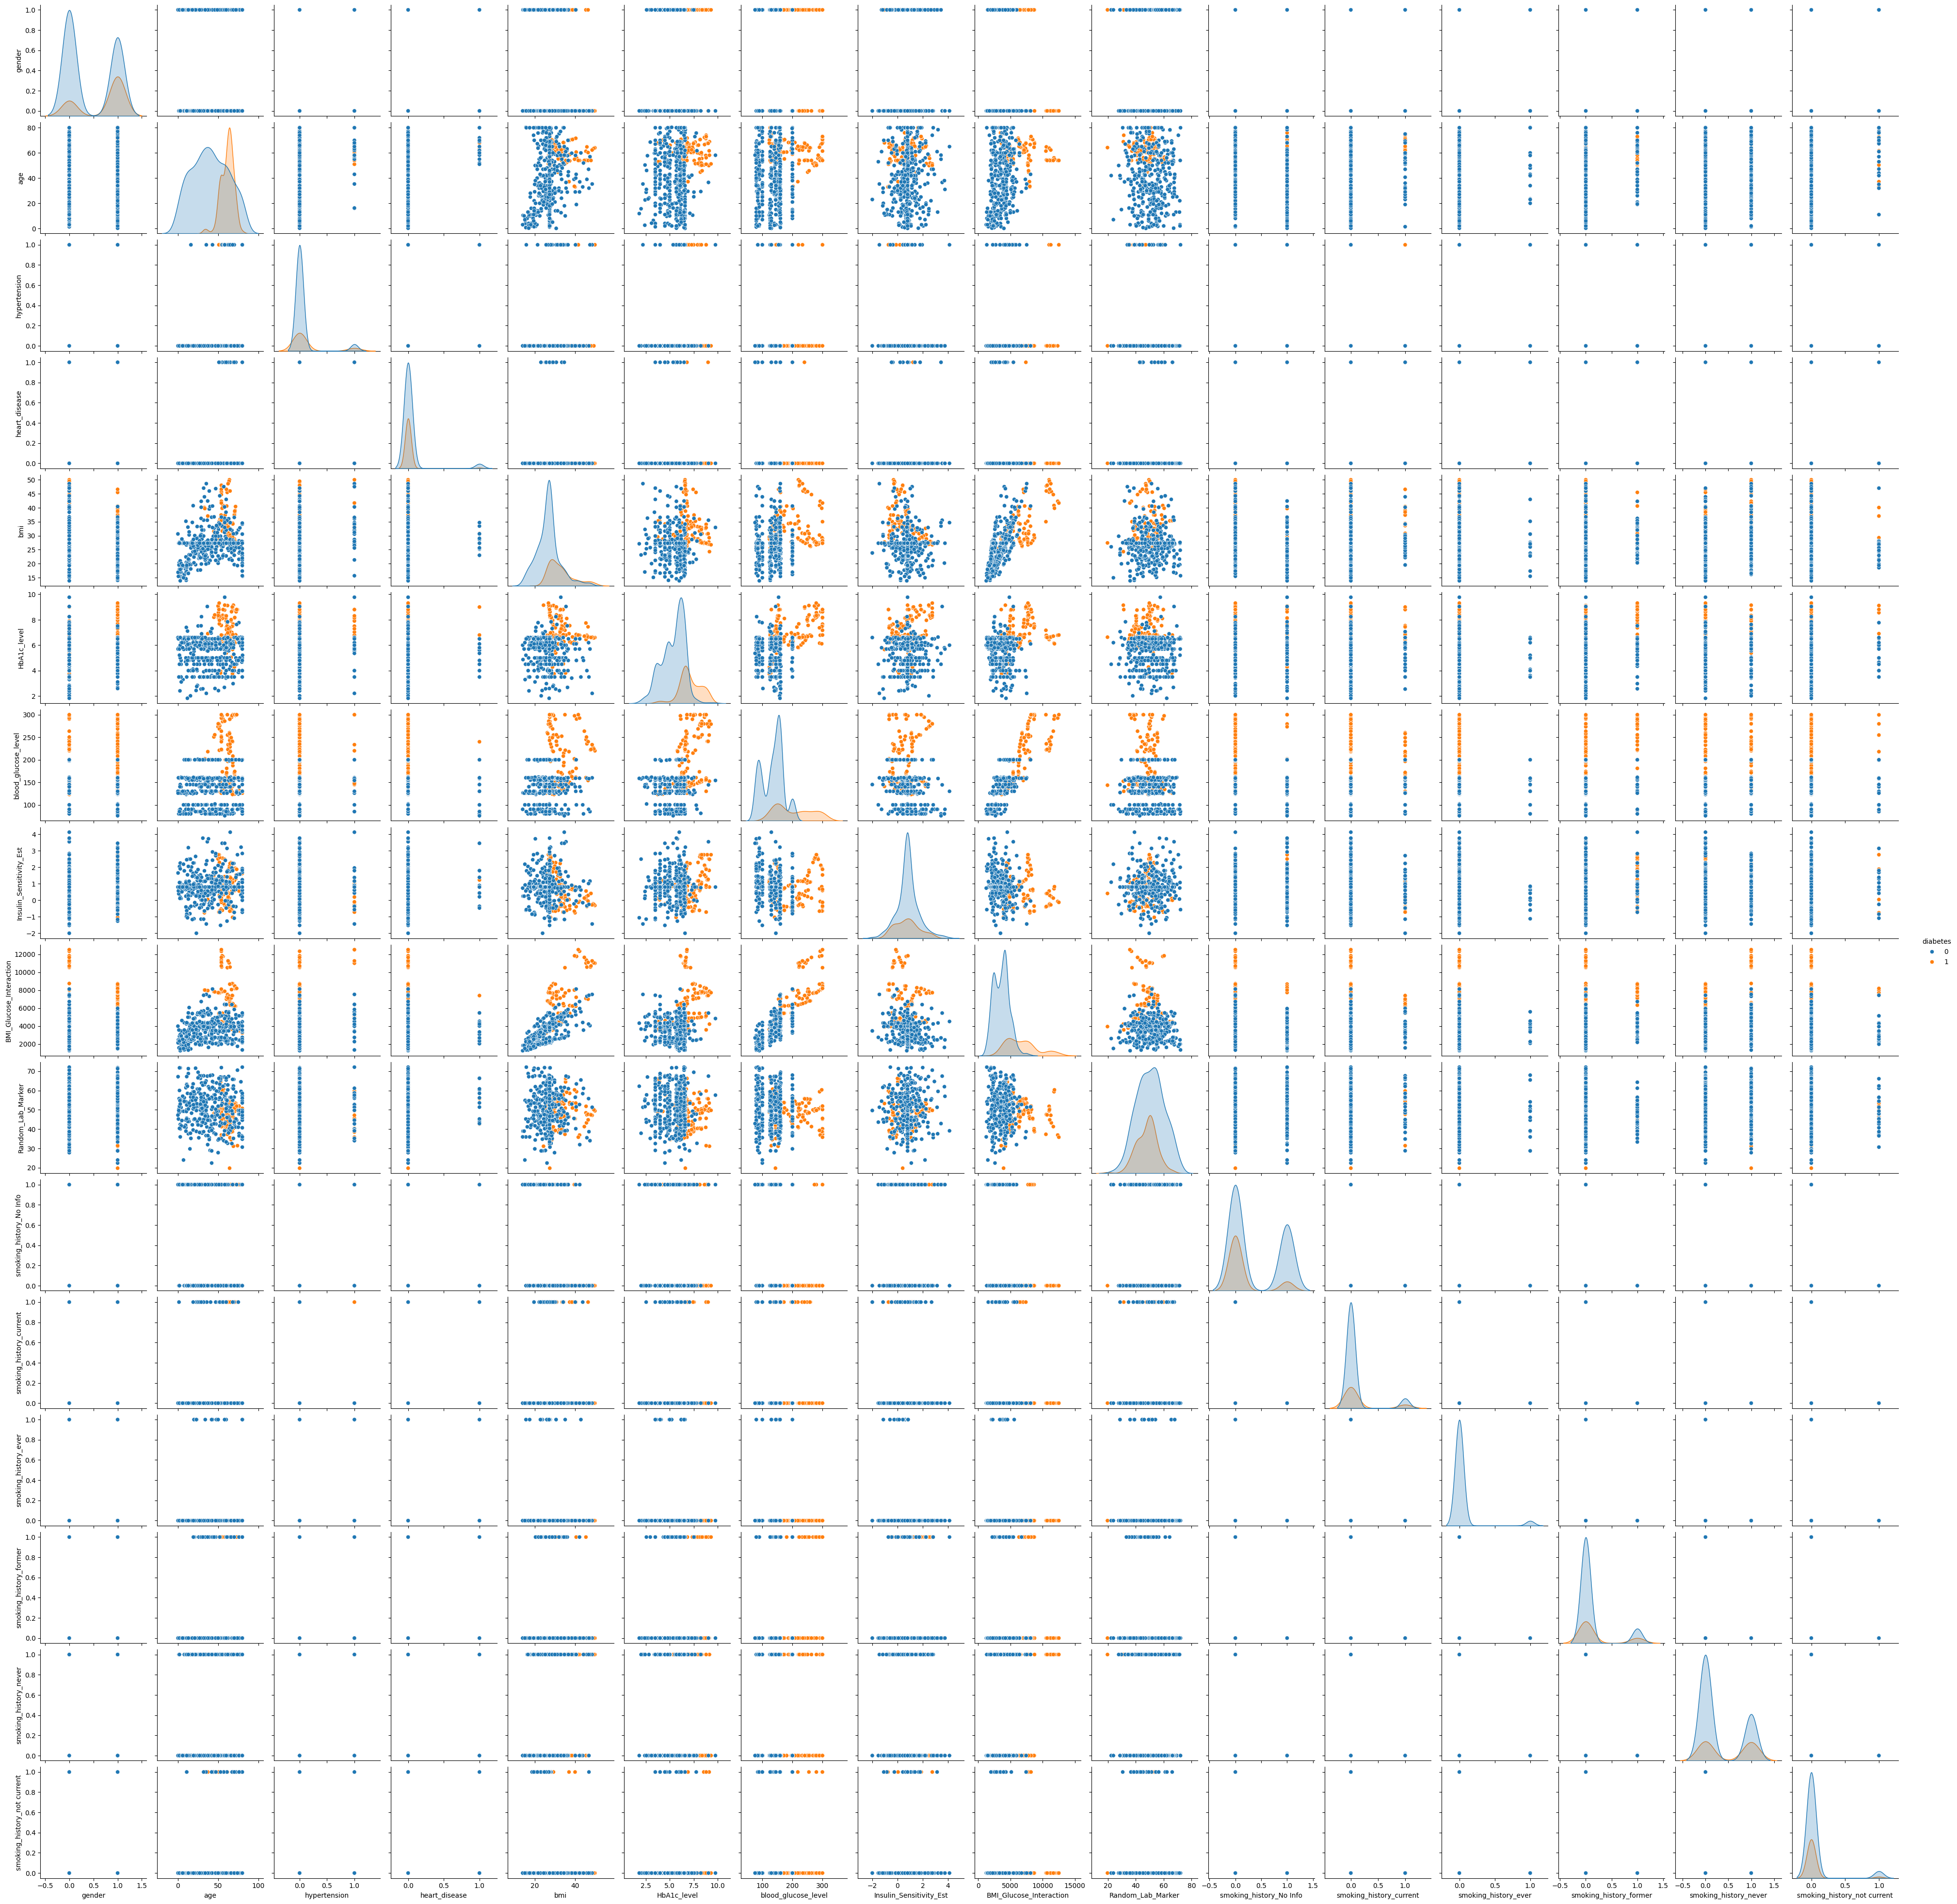

In [ ]:
# Pair plot
sns.pairplot(data_noNull_noOut, hue='diabetes')
#plt.savefig('./Plot_Analisi/PairPlot.pdf', format='pdf', bbox_inches='tight')
plt.show()

<Axes: >

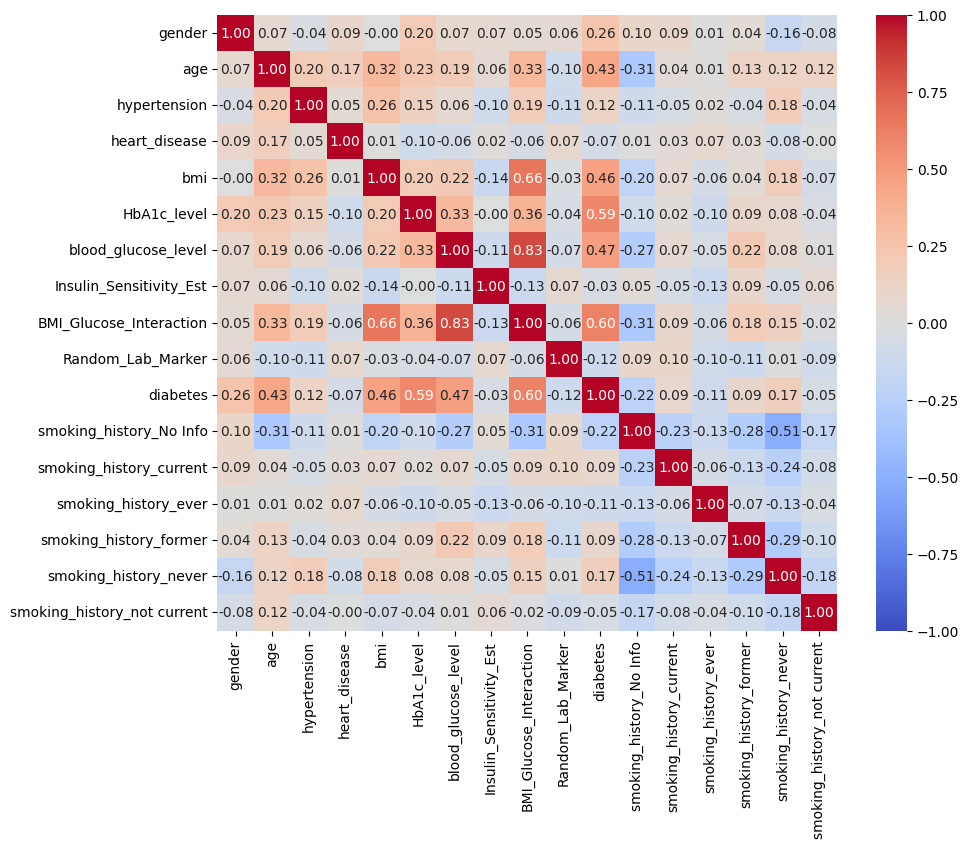

In [ ]:
#Spearman correlation between features
res = sp.stats.spearmanr(data_noNull_noOut)
corr_matrix = pd.DataFrame(res.statistic, index=data_noNull_noOut.columns, columns=data_noNull_noOut.columns)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='coolwarm')
#plt.savefig('./Plot_Analisi/Heatmap_completa.pdf', format='pdf', bbox_inches='tight')

Come previsto, l'interazione tra BMI e livello di glucosio mostra una forte correlazione sia con il glucosio stesso che con l'indice di massa corporea. Inoltre, la presenza del diabete risulta ben correlata con il livello di emoglobina glicata.

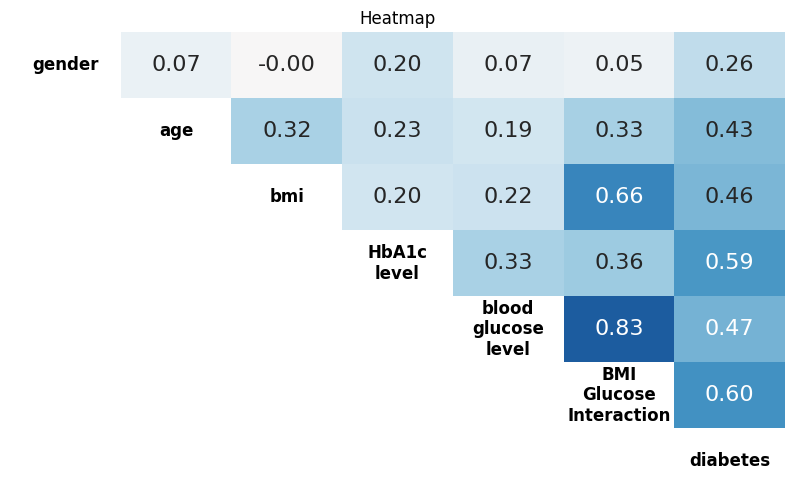

In [ ]:
# Maschera: True per nascondere i valori
variabili_rilevanti = [0,1,4,5,6,8,10]
corr_matrix_rid = corr_matrix.iloc[variabili_rilevanti, variabili_rilevanti]
mask = np.triu(np.ones_like(corr_matrix_rid, dtype=bool), k=1)

# Pulizia nomi: underscore -> spazio, vai a capo se lunghi
clean_labels = [col.replace("_", " ").replace(" ", "\n") for col in corr_matrix_rid.columns]

plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix_rid, mask=~mask, vmin=-1, vmax=1, annot=True, fmt=".2f", 
            cmap='RdBu', cbar=False, annot_kws={"size": 16})

# Inserisci le etichette al posto della diagonale
for i, label in enumerate(clean_labels):
    plt.text(i + 0.5, i + 0.5, label, ha='center', va='center',
             fontsize=12, fontweight='bold', color='black')

plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.title('Heatmap')
#plt.savefig('./Plot_Analisi/Plot_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()

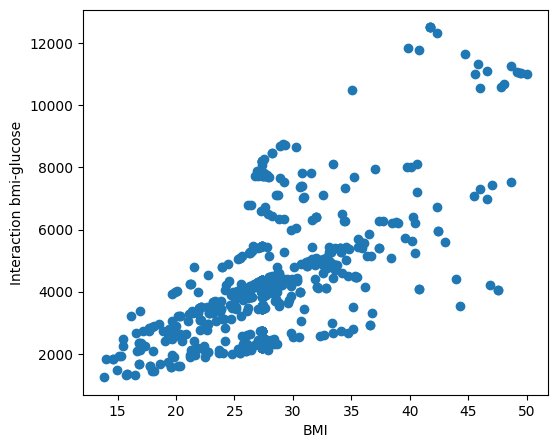

In [ ]:
fig = plt.figure(figsize=(6,5))
plt.scatter(data_noNull_noOut['bmi'], data_noNull_noOut['BMI_Glucose_Interaction'])
plt.xlabel('BMI')
plt.ylabel('Interaction bmi-glucose')
#plt.savefig('./Plot_Analisi/Plot_Corr_BmiInteraction.pdf', format='pdf', bbox_inches='tight')
plt.show()

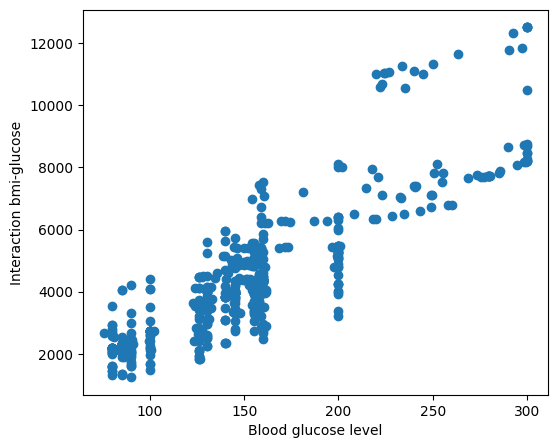

In [ ]:
fig = plt.figure(figsize=(6,5))
plt.scatter(data_noNull_noOut['blood_glucose_level'], data_noNull_noOut['BMI_Glucose_Interaction'])
plt.xlabel('Blood glucose level')
plt.ylabel('Interaction bmi-glucose')
#plt.savefig('./Plot_Analisi/Plot_Corr_GlucoseInteraction.pdf', format='pdf', bbox_inches='tight')
plt.show()